## Task 1: Linear Regression – California Housing

## 1. Data Loading & EDA

Fetching California Housing data...

--- Dataset Preview ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- Null Check ---
Nulls:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Stats:
                    mean         min           max
MedInc          3.870671    0.499900     15.000100
HouseAge   

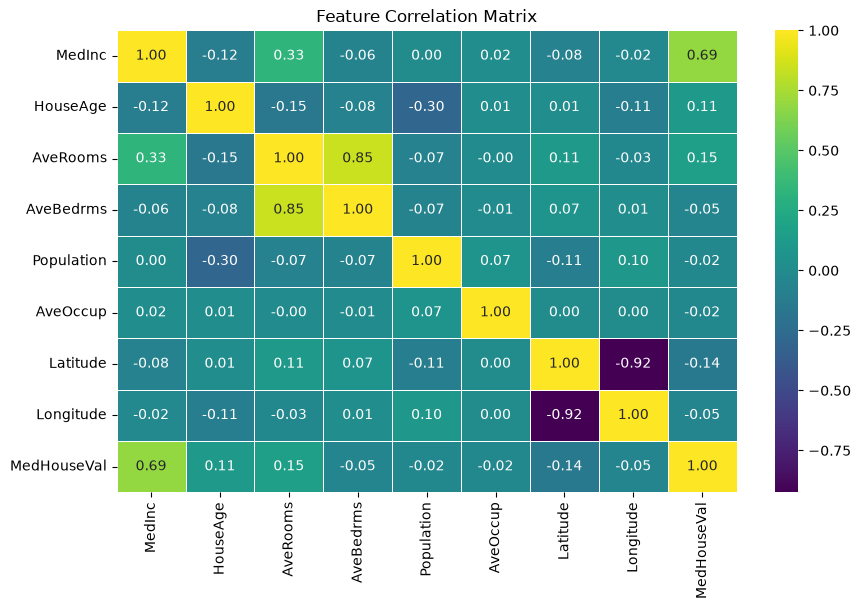

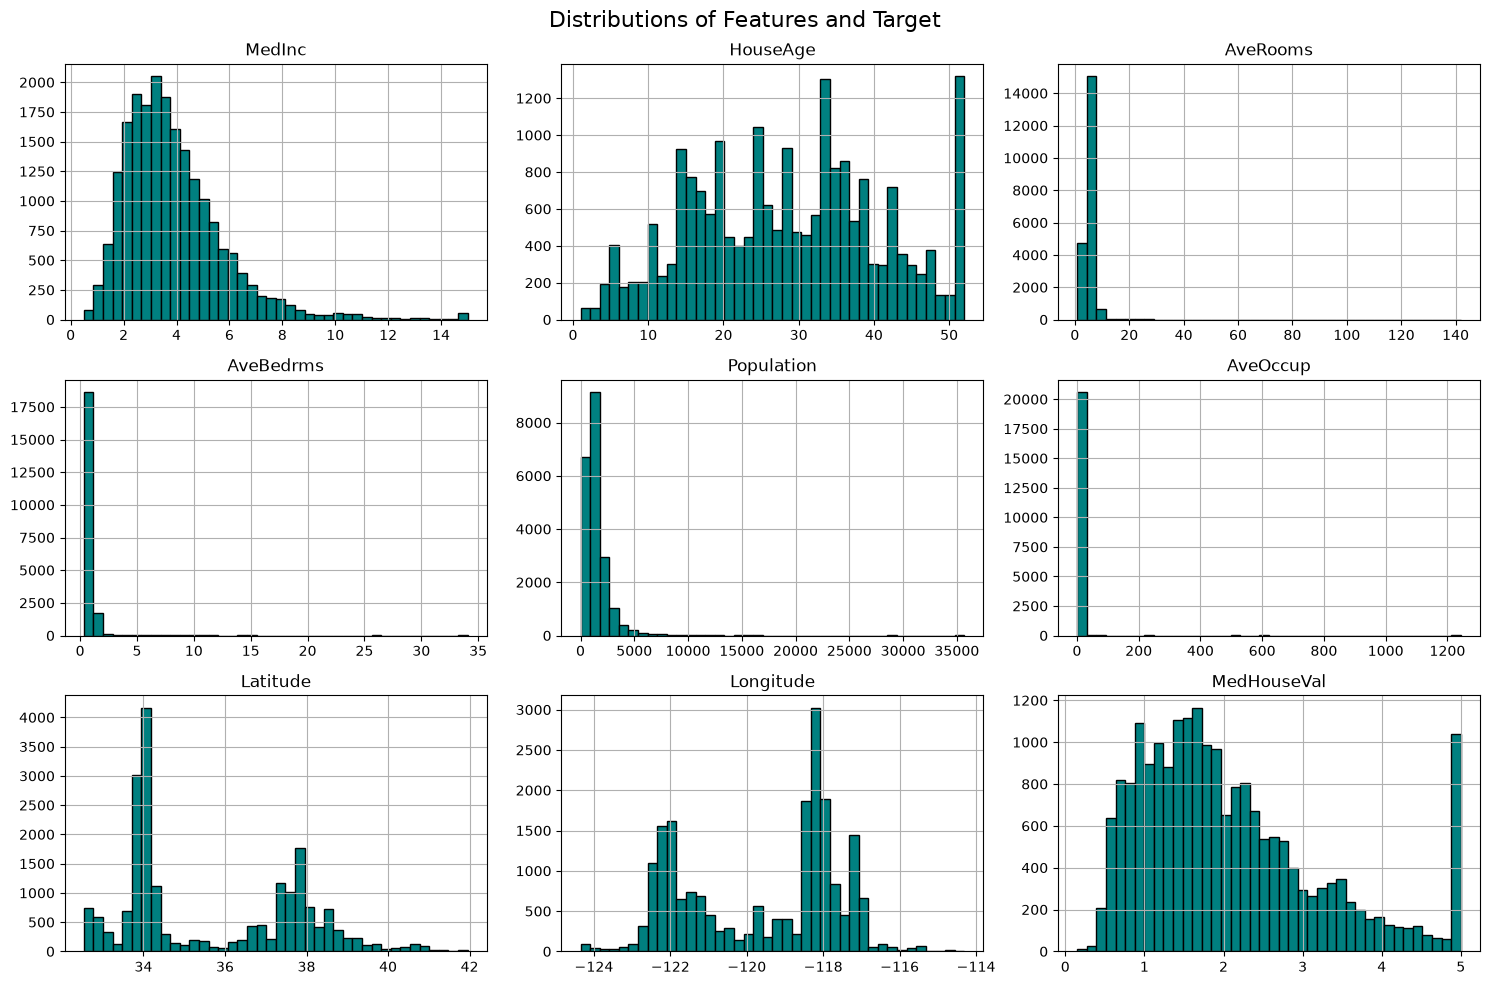

In [1]:
# Section 1: Data Loading and Exploration
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

print("Fetching California Housing data...")
housing = fetch_california_housing(as_frame=True)
data = housing.frame
features = housing.data
target = housing.target

print("\n--- Dataset Preview ---")
print(data.head())

print("\n--- Null Check ---")
print(f"Nulls:\n{data.isnull().sum()}\n")
print(f"Stats:\n{data.describe().T[['mean', 'min', 'max']]}\n")

plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

data.hist(bins=40, figsize=(15, 10), edgecolor='black', color='teal')
plt.suptitle("Distributions of Features and Target", fontsize=16)
plt.tight_layout()
plt.show()

## 2. Preprocessing: Train/Test Split & Scaling

In [2]:
# Section 2: Train/Test Split and Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=7)
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling done.")

Train shape: (15480, 8)
Test shape: (5160, 8)
Scaling done.


## 3. Model Training

In [3]:
# Section 3: Model Fitting
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)
print("Training complete.")

Training complete.


## 4. Evaluation & Plots

MAE:  0.5310
RMSE: 0.7237
R2:   0.6070


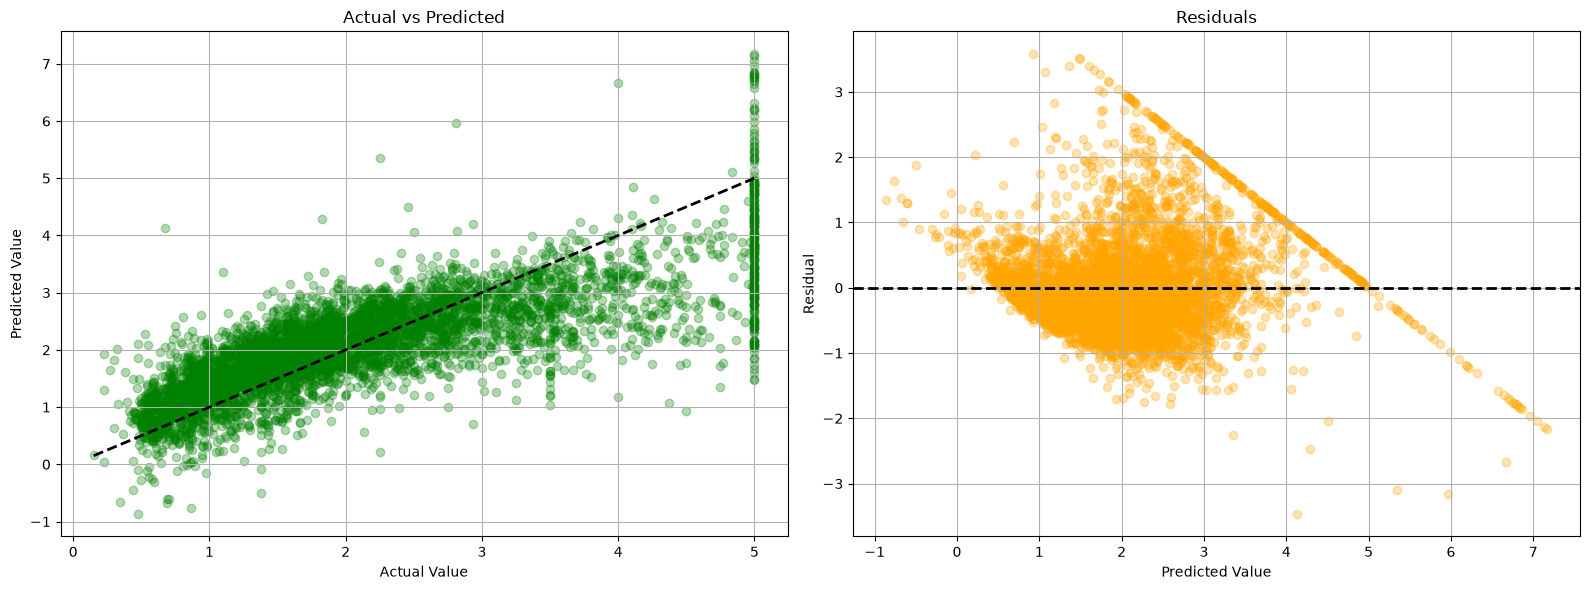

In [4]:
# Section 4: Evaluation
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preds = reg_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].scatter(y_test, preds, alpha=0.3, color='green')
ax[0].plot([target.min(), target.max()], [target.min(), target.max()], 'k--', lw=2)
ax[0].set_xlabel("Actual Value")
ax[0].set_ylabel("Predicted Value")
ax[0].set_title("Actual vs Predicted")
ax[0].grid(True)

resid = y_test - preds
ax[1].scatter(preds, resid, alpha=0.3, color='orange')
ax[1].axhline(0, color='k', linestyle='--', lw=2)
ax[1].set_xlabel("Predicted Value")
ax[1].set_ylabel("Residual")
ax[1].set_title("Residuals")
ax[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Saving Model Artifacts

In [5]:
import pickle

with open('housing_model.pkl', 'wb') as f:
    pickle.dump(reg_model, f)
with open('housing_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Artifacts saved.")

Artifacts saved.


## 6. Prediction UI Script

In [6]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

@st.cache_resource
def load_artifacts():
    with open('housing_model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('housing_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    return model, scaler

reg_model, scaler = load_artifacts()

st.title("California Housing Price Estimator")
st.write("Fill in block details:")

c1, c2 = st.columns(2)
with c1:
    inc = st.number_input("Median Income (10k USD)", value=4.0)
    age = st.number_input("House Age (yrs)", value=20.0)
    rooms = st.number_input("Avg Rooms", value=6.0)
    bed = st.number_input("Avg Bedrooms", value=1.2)
with c2:
    pop = st.number_input("Population", value=1200.0)
    occ = st.number_input("Avg Occupancy", value=3.2)
    lat = st.number_input("Latitude", value=36.0)
    lon = st.number_input("Longitude", value=-119.0)

if st.button("Estimate Price", type="primary"):
    arr = np.array([[inc, age, rooms, bed, pop, occ, lat, lon]])
    scaled = scaler.transform(arr)
    pred = reg_model.predict(scaled)[0]
    st.success(f"### Estimated Price: ${pred * 100000:,.2f}")

Overwriting app.py
